# Reanalysis of stalagmite reported by Ridley et al. (2015)
Data is reported by Ridley et al. (2015)

#### Reference 


Ridley, H., Asmerom, Y., Baldini, J. et al. Aerosol forcing of the position of the intertropical convergence zone since ad 1550. Nature Geosci 8, 195–200 (2015). https://doi.org/10.1038/ngeo2353



In [7]:
import ibis

In [8]:
from ibis import IBIS_Main

In [9]:
_META = dict(
        # depth handling
        depth_increases_down=True,
        depth_tol=0.0,  # 0 => no rounding

        # boutique sampler
        fraction_det=0.2,
        r02_clip_lo=0.001,
        r02_clip_hi=1000.0,

        # r02 max bound from data (IMPORTANT)
        r02_max_k_sigma=3.0,  # use (r08+kσ)/(r28-kσ)

        # r02 relative uncertainty proposal
        r02_err_mode="halfnorm",   # "fixed"|"uniform"|"halfnorm"
        r02_rel_err=0.25,
        r02_rel_min=0.005,
        r02_rel_max=1.0,

        # validity gates
        age_sigma_gate=2.0,
        age_eps=1e-12,

        # sigma cheating prevention (EB): default False
        use_r02_in_sigma=False,

        # batch sampler controls
        batch_size = 1000,
        max_batches=500,
        keep_frac=0.08,
        keep_factor=8,

        # layer windows
        neighbors=1,

        # pair weighting
        pair_weight_mode="exp",   # "none"|"exp"|"power"
        pair_tau_layers=2.0,
        pair_alpha=1.0,
        min_pair_weight=1e-6,

        # prior mixture
        global_mass=0.9,
        n_samples_global=4000,
        n_samples_layer=1000,

        # KDE fit controls
        kde_beta=0.8,
        bw_grid=None,
        cv=5,
        bw_subsample=3000,
        grid_n=1200,
        hi_pct=99.9,
        floor_pdf=1e-12,
    Verbose = True
    )

In [10]:
mm = IBIS_Main.IBIS('/Users/johncarter/Desktop/Ridley_2015_tester.csv',
    sample_name='Ridley_2015',          
    MCMC_samples=2000000,
    MCMC_burn_in=1000000,
    MCMC_Strat_samples=6000000,
    n_chains=3,
    Start_from_pickles=True, 
    show_bird=False, 
    method='thoth',
    strat_resolution=100, 
                    diction_meta= _META
)
 

Data loaded successfully from /Users/johncarter/Desktop/Ridley_2015_tester.csv (CSV)
All results will save to: /Users/johncarter/Desktop/Ridley_2015_folder


In [11]:
mm.Get_IBIS_Bounds()

Bounds and uncertainties file exists and is loaded.


(array([161.49133926,  91.72181454,  40.20215392,  64.03195203,
         89.1286276 , 108.6592147 , 129.10712699, 154.51928744,
        177.6035302 , 195.67016384, 222.84739912, 248.63136278,
        265.7070993 , 285.55397545, 305.10392075, 337.4258201 ,
        356.10199991, 392.72607376, 405.99520282, 434.14855306]),
 439.79246147883373,
 array([ 6.41891025, 10.15344754,  1.11699597,  1.48966891,  1.10571481,
         0.73542021,  0.37593934,  0.73811319,  1.1032692 ,  0.73682419,
         1.10312448,  1.10769533,  1.1150574 ,  0.74888199,  0.74684932,
         1.11492076,  1.12334602,  2.28123698,  1.86719773,  1.12878168]))

In [12]:
mm.Set_Up_MCMC()

[thoth] batch 1/500: valid=762 kept_total=61 (r02_hi=1e+06)
[thoth] batch 101/500: valid=774 kept_total=6211 (r02_hi=1e+06)
[thoth] batch 201/500: valid=766 kept_total=12339 (r02_hi=1e+06)
[thoth] batch 301/500: valid=735 kept_total=18482 (r02_hi=1e+06)
[thoth] batch 401/500: valid=759 kept_total=24647 (r02_hi=1e+06)
Initial thorium composition prior saved to /Users/johncarter/Desktop/Ridley_2015_folder/Ridley_2015_prior.pkl
Computed & saved Thorium prior to
 /Users/johncarter/Desktop/Ridley_2015_folder/Ridley_2015_prior.pkl


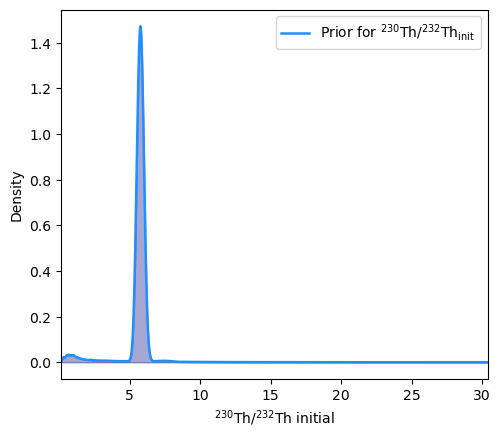

In [13]:
fig, ax =mm.Plot_Priors()
#ax.set_xlim(0, 10)

In [14]:
mm.Run_MCMC()

Generating new starting θ’s


In [15]:
# Save the summary so we can read it back in and plot it anywhere in any style we'd like
mm.SaveSummary()

IBIS summary saved to: /Users/johncarter/Desktop/Ridley_2015_folder/Ridley_2015_ibis_summary.csv
Summary saved to Ridley_2015_ibis_summary.csv


In [16]:
"""
Inside the IBIS model you can grab the instance of the initial thorium
MCMC model using .Ibis_Chains then you can access other functions. 
In particular it is useful to look at the chain diagnostics 
"""
mm.Ibis_Chains.Chain_diag_dataframe()

,Sample index (top to bottom),Initial thorium r-hat,234U_238U r-hat,232Th_238U r-hat,230Th_238U r-hat
0,1,1.000411,1.000008,1.000274,1.000046
1,2,1.000339,1.000044,1.000644,1.000038
2,3,1.000282,1.000006,1.000049,1.000154
3,4,1.025585,1.000003,1.000052,1.000054
4,5,1.008147,1.000019,1.000000,1.000033
5,6,1.005818,1.000023,1.000097,1.000341
6,7,1.007106,1.000004,1.000035,1.000042
7,8,1.044453,1.000001,1.000569,1.000057
8,9,1.024208,1.000011,1.000002,1.000108
9,10,1.003900,1.000045,1.000125,1.000096


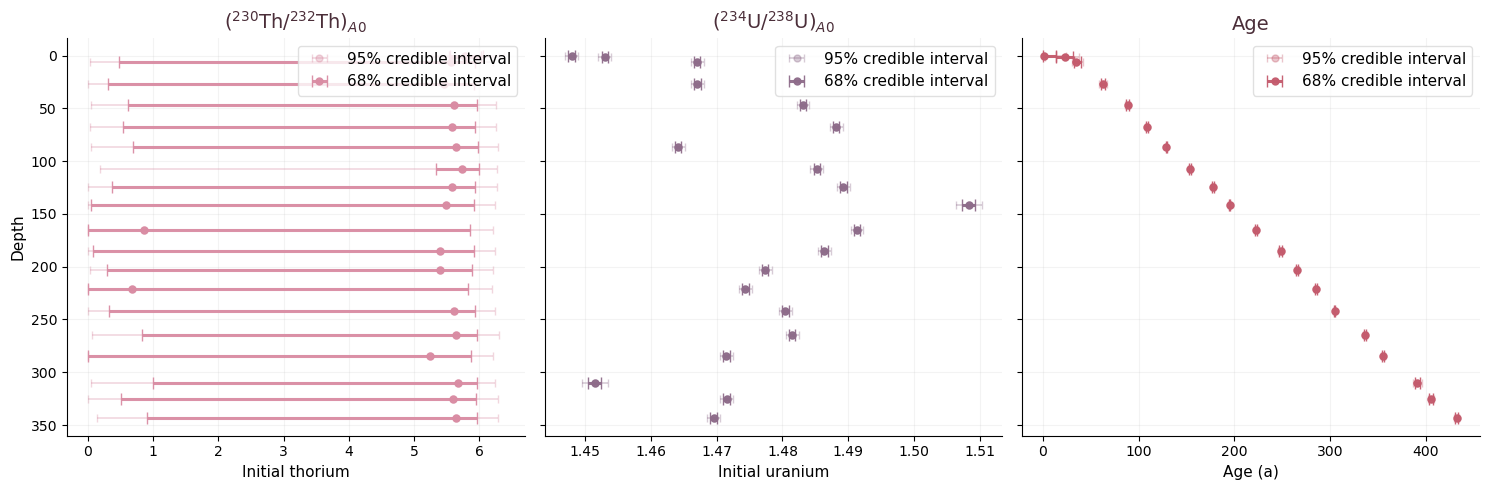

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#
# Read the data back in that we saved above
#
df_summary = pd.read_csv("/Users/johncarter/Desktop/Ridley_2015_folder/Ridley_2015_ibis_summary.csv")


# -----------------------------------
# Wes Anderson colors - https://github.com/hneutr/wesanderson
# -----------------------------------
gbh_colors = {
    "thorium": "#D98CA3",   # dusty pink
    "uranium": "#8E6C8A",   # mauve-purple
    "age": "#C45B6D",       # warm rose-red
    "light": "#F4E7D3",     # cream
    "dark": "#4B2E39"       # deep plum
}

# -----------------------------------
# Figure setup
# -----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.patch.set_facecolor("white")

# -----------------------------------
# Plot settings for each panel
# -----------------------------------
plot_info = [
    {
        "ax": axes[0],
        "x": "initial thorium",
        "xerr68": ["Th0_err_lo68", "Th0_err_hi68"],
        "xerr95": ["Th0_err_lo95", "Th0_err_hi95"],
        "title": "($^{230}$Th/$^{232}$Th)$_{A0}$",
        "xlabel": "Initial thorium",
        "color": gbh_colors["thorium"]
    },
    {
        "ax": axes[1],
        "x": "initial uranium",
        "xerr68": ["U0_err_lo68", "U0_err_hi68"],
        "xerr95": ["U0_err_lo95", "U0_err_hi95"],
        "title": "($^{234}$U/$^{238}$U)$_{A0}$",
        "xlabel": "Initial uranium",
        "color": gbh_colors["uranium"]
    },
    {
        "ax": axes[2],
        "x": "age",
        "xerr68": ["age_err_lo68", "age_err_hi68"],
        "xerr95": ["age_err_lo95", "age_err_hi95"],
        "title": "Age",
        "xlabel": "Age (a)",
        "color": gbh_colors["age"]
    }
]

# -----------------------------------
# Make the plots
# -----------------------------------
for item in plot_info:
    ax = item["ax"]
    x = df_summary[item["x"]]
    y = df_summary["Depth_Meas"]

    xerr68 = np.vstack([
        df_summary[item["xerr68"][0]],
        df_summary[item["xerr68"][1]]
    ])

    xerr95 = np.vstack([
        df_summary[item["xerr95"][0]],
        df_summary[item["xerr95"][1]]
    ])

    # 95% intervals first (lighter, behind)
    ax.errorbar(
        x=x,
        y=y,
        xerr=xerr95,
        fmt='o',
        ms=5,
        lw=1.2,
        capsize=3,
        color=item["color"],
        alpha=0.35,
        label='95% credible interval',
        zorder=1
    )

    # 68% intervals on top (stronger)
    ax.errorbar(
        x=x,
        y=y,
        xerr=xerr68,
        fmt='o',
        ms=5,
        lw=2.2,
        capsize=4,
        color=item["color"],
        alpha=0.95,
        label='68% credible interval',
        zorder=2
    )

    ax.set_title(item["title"], fontsize=14, color=gbh_colors["dark"])
    ax.set_xlabel(item["xlabel"], fontsize=11)
    ax.invert_yaxis()
    ax.grid(alpha=0.15)
    ax.legend(frameon=True, facecolor="white", edgecolor="0.85", fontsize=11, 
             loc = 'upper right')

axes[0].set_ylabel("Depth", fontsize=11)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Lets make some nice plots 
* Z-scored initial thorium and initial uranium on the same age axis

* I'll use a Gaussian smoothing kernel to keep the general properties of the data but smooth the relationship for nice visuals

* Going to remove the relatively high initial thorium value > 50, just for visualization

In [19]:
# =========================================================
# Helper function - data from IBIS is likely to assymetric so we 
# want to sample both left and right uncertainties
# =========================================================
def sample_split_normal(mu, sig_lo, sig_hi, rng):
    mu = np.asarray(mu, dtype=float)
    sig_lo = np.asarray(sig_lo, dtype=float)
    sig_hi = np.asarray(sig_hi, dtype=float)

    p_left = sig_lo / (sig_lo + sig_hi + 1e-15)
    u = rng.random(mu.shape)
    left = u < p_left

    z = np.abs(rng.normal(size=mu.shape))
    out = mu.copy()
    out[left]  = mu[left]  - z[left]  * sig_lo[left]
    out[~left] = mu[~left] + z[~left] * sig_hi[~left]
    return out


# =========================================================
# Guassian kernel smoother
# =========================================================
def kernel_smoother(x_grid, x, y, bandwidth):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    yhat = np.full_like(x_grid, np.nan, dtype=float)

    for i, x0 in enumerate(x_grid):
        w = np.exp(-0.5 * ((x - x0) / bandwidth)**2)
        sw = np.sum(w)
        if sw > 0:
            yhat[i] = np.sum(w * y) / sw

    return yhat


# =========================================================
# Monte Carlo method
# =========================================================
def mc_smooth_envelope(age, age_lo, age_hi,
                       y, y_lo, y_hi,
                       x_grid=None,
                       n_mc=2000,
                       bandwidth=None,
                       random_seed=42):
    rng = np.random.default_rng(random_seed)

    age = np.asarray(age, dtype=float)
    age_lo = np.asarray(age_lo, dtype=float)
    age_hi = np.asarray(age_hi, dtype=float)
    y = np.asarray(y, dtype=float)
    y_lo = np.asarray(y_lo, dtype=float)
    y_hi = np.asarray(y_hi, dtype=float)

    y_mean = np.nanmean(y)
    y_std = np.nanstd(y, ddof=1)
    y_z = (y - y_mean) / y_std
    yerr_z = np.vstack([y_lo / y_std, y_hi / y_std])

    if x_grid is None:
        xmin = np.nanmin(age - age_lo)
        xmax = np.nanmax(age + age_hi)
        x_grid = np.linspace(xmin, xmax, 300)


    curves = np.full((n_mc, x_grid.size), np.nan)

    for i in range(n_mc):
        age_s = sample_split_normal(age, age_lo, age_hi, rng)
        y_s   = sample_split_normal(y, y_lo, y_hi, rng)

        y_s_z = (y_s - y_mean) / y_std
        curves[i, :] = kernel_smoother(x_grid, age_s, y_s_z, bandwidth)

    p2_5, p16, p50, p84, p97_5 = np.nanpercentile(
        curves, [2.5, 16, 50, 84, 97.5], axis=0
    )

    return {
        "x_grid": x_grid,
        "median": p50,
        "lo68": p16,
        "hi68": p84,
        "lo95": p2_5,
        "hi95": p97_5,
        "y_z": y_z,
        "yerr_z": yerr_z,
    }


In [20]:
# filter out that really high point - better visual 
df_summary = df_summary[df_summary["initial thorium"] <= 40].copy()

age     = df_summary["age"].values
age_lo  = df_summary["age_err_lo68"].values
age_hi  = df_summary["age_err_hi68"].values

th      = df_summary["initial thorium"].values
th_lo   = df_summary["Th0_err_lo68"].values
th_hi   = df_summary["Th0_err_hi68"].values

u       = df_summary["initial uranium"].values
u_lo    = df_summary["U0_err_lo68"].values
u_hi    = df_summary["U0_err_hi68"].values

# =========================================================
# Make common age grid
# =========================================================
xmin = np.nanmin(age - age_lo)
xmax = np.nanmax(age + age_hi)
x_grid = np.linspace(xmin, xmax, 5000)
bandwidth = 0.10 * (xmax - xmin)

# =========================================================
# Monte Carlo out the smoothed envelopes
# =========================================================
res_th = mc_smooth_envelope(
    age, age_lo, age_hi,
    th, th_lo, th_hi,
    x_grid=x_grid,
    n_mc=2000,
    bandwidth=2,
    random_seed=123
)

res_u = mc_smooth_envelope(
    age, age_lo, age_hi,
    u, u_lo, u_hi,
    x_grid=x_grid,
    n_mc=2000,
    bandwidth=2,
    random_seed=123
)



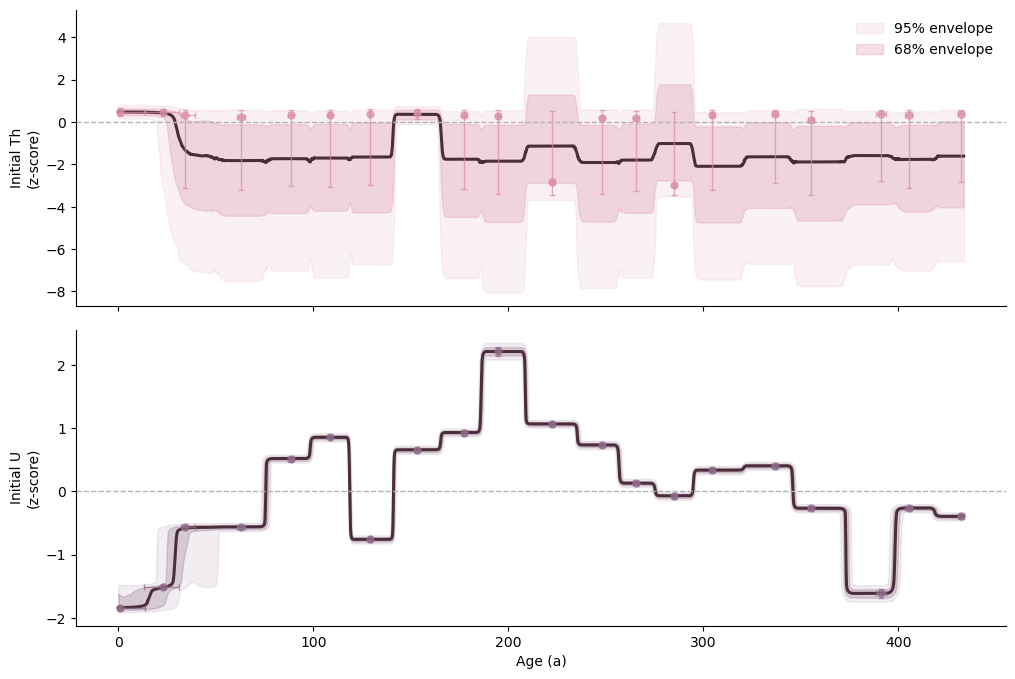

In [21]:
# =========================================================
# Make the Plot
# =========================================================
thor_color = "#D98CA3"
uran_color = "#8E6C8A"
dark_line  = "#4B2E39"

fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"hspace": 0.08}
)

# ---------------------------
# Panel 1: Initial thorium
# ---------------------------
ax = axes[0]
ax.fill_between(res_th["x_grid"], res_th["lo95"], res_th["hi95"],
                color=thor_color, alpha=0.12, label="95% envelope")
ax.fill_between(res_th["x_grid"], res_th["lo68"], res_th["hi68"],
                color=thor_color, alpha=0.28, label="68% envelope")
ax.plot(res_th["x_grid"], res_th["median"], color=dark_line, lw=2.2)

ax.errorbar(
    age, res_th["y_z"],
    xerr=np.vstack([age_lo, age_hi]),
    yerr=res_th["yerr_z"],
    fmt="o", ms=5,
    color=thor_color,
    ecolor=thor_color,
    alpha=0.7, capsize=2, lw=1
)

ax.axhline(0, color="0.7", lw=1, ls="--")
ax.set_ylabel("Initial Th\n(z-score)")
ax.legend(frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------
# Panel 2: Initial uranium
# ---------------------------
ax = axes[1]
ax.fill_between(res_u["x_grid"], res_u["lo95"], res_u["hi95"],
                color=uran_color, alpha=0.12, label="95% envelope")
ax.fill_between(res_u["x_grid"], res_u["lo68"], res_u["hi68"],
                color=uran_color, alpha=0.28, label="68% envelope")
ax.plot(res_u["x_grid"], res_u["median"], color=dark_line, lw=2.2)

ax.errorbar(
    age, res_u["y_z"],
    xerr=np.vstack([age_lo, age_hi]),
    yerr=res_u["yerr_z"],
    fmt="o", ms=5,
    color=uran_color,
    ecolor=uran_color,
    alpha=0.7, capsize=2, lw=1
)

ax.axhline(0, color="0.7", lw=1, ls="--")
ax.set_ylabel("Initial U\n(z-score)")
ax.set_xlabel("Age (a)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.show()

In [22]:
df = pd.read_excel('/Users/johncarter/Desktop/Ridley_2015_Carbon.xlsx', sheet_name = 'd13C data')

In [23]:
u_lo    = df_summary["U0_err_lo95"].values
u_hi    = df_summary["U0_err_hi95"].values

Text(0, 0.5, '($^{234}$U/$^{238}$U)$_{A0}$')

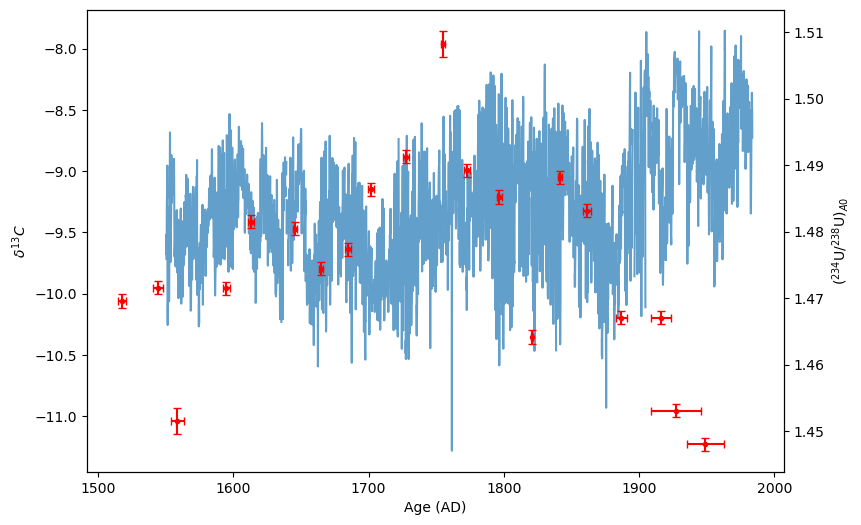

In [24]:
fig, ax = plt.subplots(1, 1, figsize = (9,6))
ax.plot(df['Year (AD)'], df['13C/12C'], alpha = 0.7)
ax2 = ax.twinx()
ax2.errorbar(x = 1950 -df_summary['age'], 
             xerr = df_summary['age_err_sym'] * 2, 
             y = df_summary['initial uranium'], 
           yerr = np.vstack([u_lo, u_hi]), 
            fmt = 'o', capsize = 3, 
            markersize = 3, 
            zorder = 1000, 
            color= 'r')


ax.set_ylabel('$\delta^{13}C$')
ax.set_xlabel('Age (AD)')
ax2.set_ylabel('($^{234}$U/$^{238}$U)$_{A0}$')


In [25]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# -------------------------------
# Clean and sort δ13C time series
# -------------------------------
c13 = df[['Year (AD)', '13C/12C']].dropna().sort_values('Year (AD)')

time_c13 = c13['Year (AD)'].values
d13c = c13['13C/12C'].values

# -------------------------------
# U-series dated points
# -------------------------------
time_u = 1950 - df_summary['age'].values
u_init = df_summary['initial uranium'].values

# Keep only uranium dates within the δ13C record's time range
mask = (
    np.isfinite(time_u) &
    np.isfinite(u_init) &
    (time_u >= time_c13.min()) &
    (time_u <= time_c13.max())
)

time_u_match = time_u[mask]
u_init_match = u_init[mask]

# Interpolate δ13C at each U-series date
d13c_at_u_dates = np.interp(time_u_match, time_c13, d13c)

In [26]:
r_pearson, p_pearson = pearsonr(d13c_at_u_dates, u_init_match)

print(f"Pearson r = {r_pearson:.3f}")
print(f"p-value = {p_pearson:.4f}")

Pearson r = -0.508
p-value = 0.0312


In [27]:
r_spearman, p_spearman = spearmanr(d13c_at_u_dates, u_init_match)

print(f"Spearman rho = {r_spearman:.3f}")
print(f"p-value = {p_spearman:.4f}")

Spearman rho = -0.534
p-value = 0.0226


In [29]:
from scipy.stats import pearsonr, spearmanr

n_mc = 10000

ages = df_summary['age'].values
age_sigma = df_summary['age_err_sym'].values
u_init = df_summary['initial uranium'].values

pearson_rs = []
spearman_rs = []

rng = np.random.default_rng(42)

for _ in range(n_mc):

    # Sample ages in years BP
    ages_mc = rng.normal(ages, age_sigma)

    # Convert to Year AD
    time_u_mc = 1950 - ages_mc

    # Keep points inside δ13C time range
    mask_mc = (
        np.isfinite(time_u_mc) &
        np.isfinite(u_init) &
        (time_u_mc >= time_c13.min()) &
        (time_u_mc <= time_c13.max())
    )

    if mask_mc.sum() < 3:
        continue

    # Interpolate δ13C at sampled U-Th dates
    d13c_mc = np.interp(time_u_mc[mask_mc], time_c13, d13c)
    u_mc = u_init[mask_mc]

    # Correlations
    pearson_rs.append(pearsonr(d13c_mc, u_mc)[0])
    spearman_rs.append(spearmanr(d13c_mc, u_mc)[0])

pearson_rs = np.array(pearson_rs)
spearman_rs = np.array(spearman_rs)

In [30]:
print(
    "Pearson r:",
    f"{np.median(pearson_rs):.3f}",
    f"[{np.percentile(pearson_rs, 2.5):.3f}, {np.percentile(pearson_rs, 97.5):.3f}]"
)

print(
    "Spearman rho:",
    f"{np.median(spearman_rs):.3f}",
    f"[{np.percentile(spearman_rs, 2.5):.3f}, {np.percentile(spearman_rs, 97.5):.3f}]"
)

Pearson r: -0.322 [-0.610, 0.078]
Spearman rho: -0.286 [-0.633, 0.123]


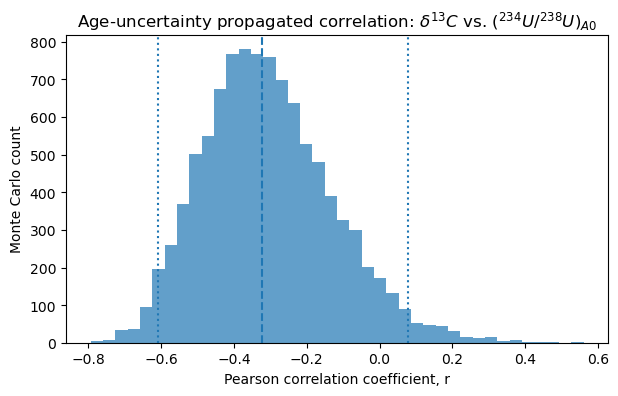

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(pearson_rs, bins=40, alpha=0.7)

ax.axvline(np.median(pearson_rs), linestyle='--')
ax.axvline(np.percentile(pearson_rs, 2.5), linestyle=':')
ax.axvline(np.percentile(pearson_rs, 97.5), linestyle=':')

ax.set_xlabel('Pearson correlation coefficient, r')
ax.set_ylabel('Monte Carlo count')
ax.set_title(r'Age-uncertainty propagated correlation: $\delta^{13}C$ vs. $(^{234}U/^{238}U)_{A0}$')

plt.show()

In [32]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


c13 = (
    df[['Year (AD)', '13C/12C']]
    .dropna()
    .sort_values('Year (AD)')
)

time_c13 = c13['Year (AD)'].to_numpy()
d13c = c13['13C/12C'].to_numpy()


time_u = 1950 - df_summary['age'].to_numpy()
u_init = df_summary['initial uranium'].to_numpy()

In [33]:
mask_0 = (
    np.isfinite(time_u) &
    np.isfinite(u_init) &
    (time_u >= time_c13.min()) &
    (time_u <= time_c13.max())
)

time_u_0 = time_u[mask_0]
u_init_0 = u_init[mask_0]

d13c_at_u_0 = np.interp(time_u_0, time_c13, d13c)

X = sm.add_constant(d13c_at_u_0)
ols_0 = sm.OLS(u_init_0, X).fit()

print(ols_0.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     5.577
Date:                Wed, 20 May 2026   Prob (F-statistic):             0.0312
Time:                        14:29:08   Log-Likelihood:                 52.576
No. Observations:                  18   AIC:                            -101.2
Df Residuals:                      16   BIC:                            -99.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3512      0.053     25.527      0.0

In [34]:
intercept = ols_0.params[0]
slope = ols_0.params[1]

print(f"Intercept = {intercept:.4f}")
print(f"Slope     = {slope:.4f}")
print(f"R²        = {ols_0.rsquared:.3f}")
print(f"p-value   = {ols_0.pvalues[1]:.4g}")

Intercept = 1.3512
Slope     = -0.0131
R²        = 0.258
p-value   = 0.03121


In [35]:
ols_0.conf_int()

array([[ 1.23899884e+00,  1.46342238e+00],
       [-2.49481810e-02, -1.34522858e-03]])

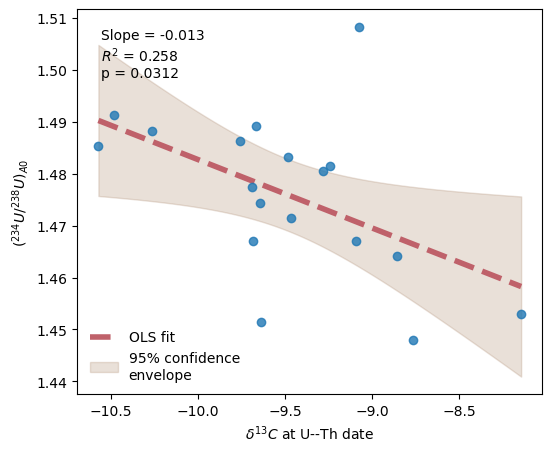

In [38]:

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    d13c_at_u_0,
    u_init_0,
    alpha=0.8,
    zorder=10
)

x_line = np.linspace(
    d13c_at_u_0.min(),
    d13c_at_u_0.max(),
    300
)

X_line = sm.add_constant(x_line)

pred = ols_0.get_prediction(X_line)
pred_frame = pred.summary_frame(alpha=0.05)

ax.plot(
    x_line,
    pred_frame["mean"],
    linewidth=4,
    ls = '--',
    label="OLS fit", 
    color = "#BF616A"
)

ax.fill_between(
    x_line,
    pred_frame["mean_ci_lower"],
    pred_frame["mean_ci_upper"],
    alpha=0.25,
    label="95% confidence\nenvelope", 
    color=  "#A98467"
)

ax.set_xlabel(r'$\delta^{13}C$ at U--Th date')
ax.set_ylabel(r'$(^{234}U/^{238}U)_{A0}$')

ax.text(
    0.05, 0.95,
    f"Slope = {ols_0.params[1]:.3f}\n"
    f"$R^2$ = {ols_0.rsquared:.3f}\n"
    f"p = {ols_0.pvalues[1]:.3g}",
    transform=ax.transAxes,
    va='top'
)

ax.legend(frameon=False, loc = 'lower left')

plt.show()

# Notes 
--------
Ridley et al. (2015) observations: 

* more positive $\delta^{13}$C $\longrightarrow$ drier conditions / reduced recharge
* more negative $\delta^{13}$C $\longrightarrow$ wetter conditions / greater recharge

<br>
The initial uranium activity ratio appears to be genuinely anticorrelated suggesting that if we take the opposite interpretation: 
<br>
greater ($^{234}$U/$^{238}$U)$_{A0}$ more positive $\longrightarrow$ wetter conditions / greater recharge and vice versa.

## What might be going on? 
Wetter intervals might be mobilizing enriched ($^{234}$U/$^{238}$U)$_{A0}$ to the karst system? 

Oster et al. show that substantial changes in speleothem ($^{234}$U/$^{238}$U)$_{A0}$ may reflect flow-path changes and interaction with host rock of varying uranium concentration rather than the simple wetter means higher ($^{234}$U/$^{238}$U)$_{A0}$ as I am saying at face-value. Its probably all very nuanced. 

<br>

The negative relationship/associated between ($^{234}$U/$^{238}$U)$_{A0}$ and $\delta^{13}$C suggest that the initial uranium may be more the by-product of longer water residence. It may instead record changes in chemistry, soil interaction, or flow-path mixing. Can't really say more but is it interesting. 


Oster, J. L., Ronay, E. R., Sharp, W. D., Breitenbach, S. F. M., & Furbish, D. J. (2023). Controls on speleothem initial 234U/238U ratios in a monsoon climate. Geochemistry, Geophysics, Geosystems, 24, e2023GC010899. https://doi.org/10.1029/2023GC010899

